# Executive Summary

Marketing teams often allocate promotional resources uniformly across all customers, leading to inefficient spending and lower return on investment (ROI). This project demonstrates how customer segmentation using Recency, Frequency, and Monetary (RFM) analysis combined with K-Means clustering can identify high-value customer groups, prioritize retention efforts, and support data-driven marketing decisions.

Using a real-world e-commerce dataset containing 541,909 transactions from 4,338 customers, this project develops an end-to-end analytics workflow including data cleaning, exploratory analysis, feature engineering, clustering, statistical validation, and business recommendations.

# Data-Driven Customer Segmentation for Marketing Optimization

## Business Problem

An e-commerce company has a limited marketing budget and cannot treat all customers
equally. The company needs to answer four key questions:

1. Which customers deserve loyalty rewards? (highest value, most engaged)
2. Which customers are at risk of leaving? (declining engagement)
3. Which customers generate the highest revenue? (VIP segment)
4. Which customers are new and need onboarding? (recent, low engagement)

This project segments customers using RFM (Recency, Frequency, Monetary) analysis
combined with K-Means clustering to answer these questions and provide
actionable, segment-specific marketing recommendations.

**Author:** Tsend-Ayush Ganbold

In [1]:
!wget -q -O online_retail.csv "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"
print("Downloaded successfully")

Downloaded successfully


## Dataset

**Source:** UCI Machine Learning Repository — Online Retail Dataset
541,909 transactions | 4,338 unique customers | UK-based online retailer | Dec 2010 – Dec 2011

Columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

In [2]:
import pandas as pd
df = pd.read_csv("online_retail.csv", encoding="latin1")
print(f"Shape: {df.shape}")
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data Cleaning

Cleaning checklist:
- Remove cancelled orders (InvoiceNo starting with "C")
- Remove rows with missing CustomerID (cannot segment an unknown customer)
- Remove negative/zero Quantity and UnitPrice (data errors, not real purchases)
- Create Revenue = Quantity × UnitPrice

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
before = len(df)

df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["CustomerID"] = df["CustomerID"].astype(int)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Rows before cleaning: 541,909
Rows after cleaning: 397,884
Unique customers: 4,338
Date range: 2010-12-01 to 2011-12-09


## Exploratory Data Analysis

Before segmenting, understand the overall business picture: where does revenue come from,
and how does it trend over time?

/tmp/ipykernel_913/3744202228.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index("InvoiceDate").resample("M")["Revenue"].sum()


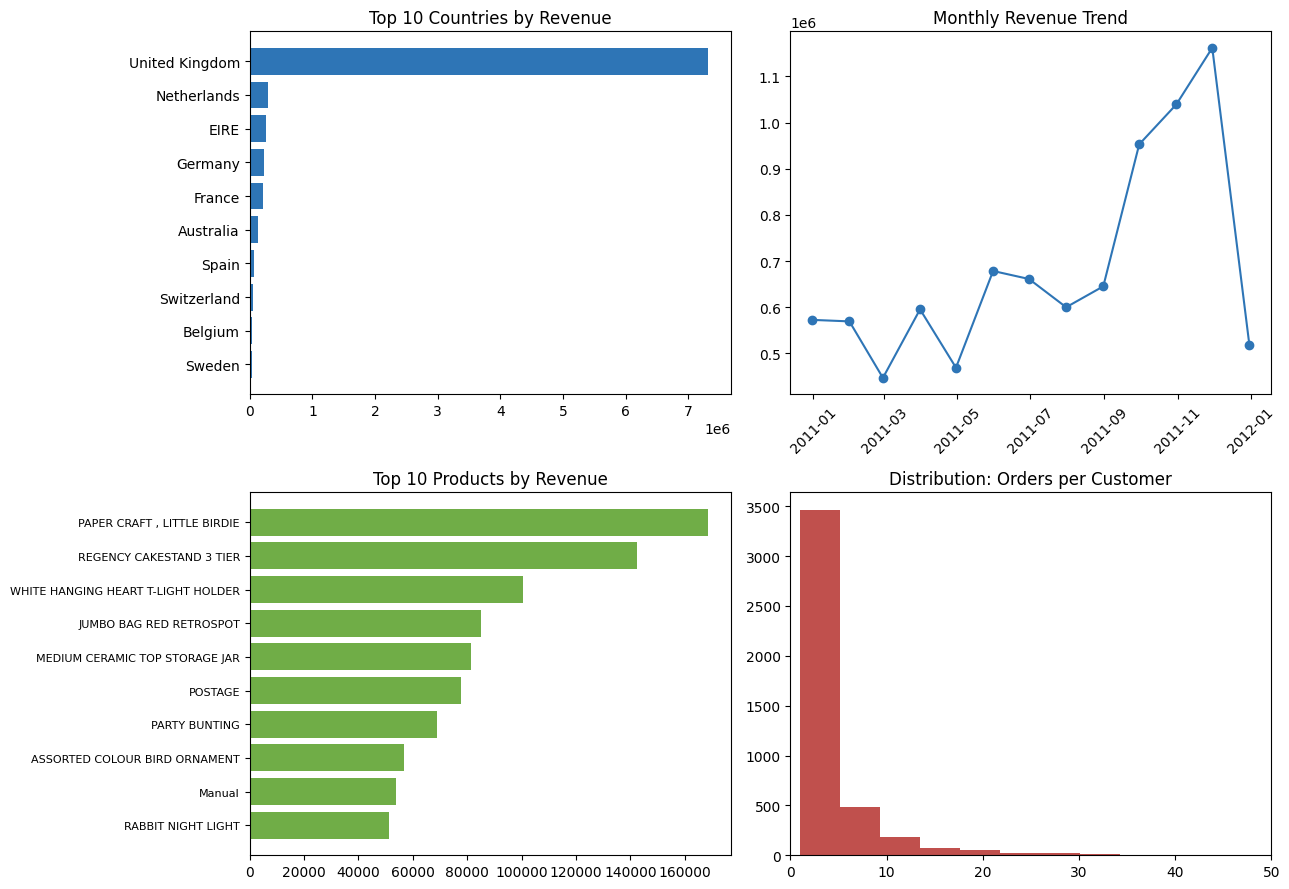


Insight: UK accounts for 82.0% of total revenue


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Top countries by revenue
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
axes[0,0].barh(top_countries.index[::-1], top_countries.values[::-1], color="#2E75B6")
axes[0,0].set_title("Top 10 Countries by Revenue")

# Monthly revenue trend
monthly = df.set_index("InvoiceDate").resample("M")["Revenue"].sum()
axes[0,1].plot(monthly.index, monthly.values, color="#2E75B6", marker="o")
axes[0,1].set_title("Monthly Revenue Trend")
axes[0,1].tick_params(axis="x", rotation=45)

# Top products
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
axes[1,0].barh(top_products.index[::-1], top_products.values[::-1], color="#70AD47")
axes[1,0].set_title("Top 10 Products by Revenue")
axes[1,0].tick_params(axis="y", labelsize=8)

# Orders per customer distribution
orders_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()
axes[1,1].hist(orders_per_customer, bins=50, color="#C0504D")
axes[1,1].set_xlim(0, 50)
axes[1,1].set_title("Distribution: Orders per Customer")

plt.tight_layout()
plt.show()

print(f"\nInsight: UK accounts for {df[df['Country']=='United Kingdom']['Revenue'].sum()/df['Revenue'].sum()*100:.1f}% of total revenue")

# Business Objectives & Success Metrics

The primary business objective is to optimize marketing resource allocation by identifying customer segments with different business values.

Success will be evaluated using the following business KPIs:

- Increase Customer Retention Rate
- Increase Customer Lifetime Value (CLV)
- Improve Repeat Purchase Rate
- Increase Marketing Campaign Conversion Rate
- Reduce Customer Acquisition Cost (CAC)
- Improve Return on Marketing Investment (ROMI)

Although these KPIs cannot be directly measured using this historical dataset, the segmentation framework provides actionable customer groups that support these business goals.

## Feature Engineering: RFM

- **Recency** — days since last purchase (lower = more engaged)
- **Frequency** — number of distinct orders (higher = more loyal)
- **Monetary** — total amount spent (higher = more valuable)

In [5]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

rfm.describe().round(1)

,CustomerID,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0,4338.0
mean,15300.4,92.5,4.3,2054.3
std,1721.8,100.0,7.7,8989.2
min,12346.0,1.0,1.0,3.8
25%,13813.2,18.0,1.0,307.4
50%,15299.5,51.0,2.0,674.5
75%,16778.8,142.0,5.0,1661.7
max,18287.0,374.0,209.0,280206.0


# Why RFM?

Customer value cannot be measured by spending alone.

RFM captures three complementary behavioral dimensions:

- **Recency** measures how recently a customer made a purchase. Customers who purchased recently are generally more likely to purchase again.

- **Frequency** measures purchasing habit and customer loyalty.

- **Monetary** measures the customer's economic contribution.

Combining these three variables provides a balanced representation of customer engagement and business value.

## Scaling

RFM distributions are heavily right-skewed (a small number of wholesale buyers place many
high-value orders). K-Means uses Euclidean distance, which is distorted by skewed, unscaled
features — so we log-transform before scaling.

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
print("Scaled. Mean ~0, Std ~1 per feature:")
print(pd.DataFrame(X_scaled, columns=["Recency","Frequency","Monetary"]).describe().round(2))

Scaled. Mean ~0, Std ~1 per feature:
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     -0.00      -0.00      0.00
std       1.00       1.00      1.00
min      -2.34      -0.96     -4.00
25%      -0.66      -0.96     -0.69
50%       0.09      -0.36     -0.06
75%       0.84       0.65      0.65
max       1.56       5.86      4.73


## Choosing the Number of Clusters (K)

We use both the Elbow Method and Silhouette Score, rather than picking K arbitrarily.

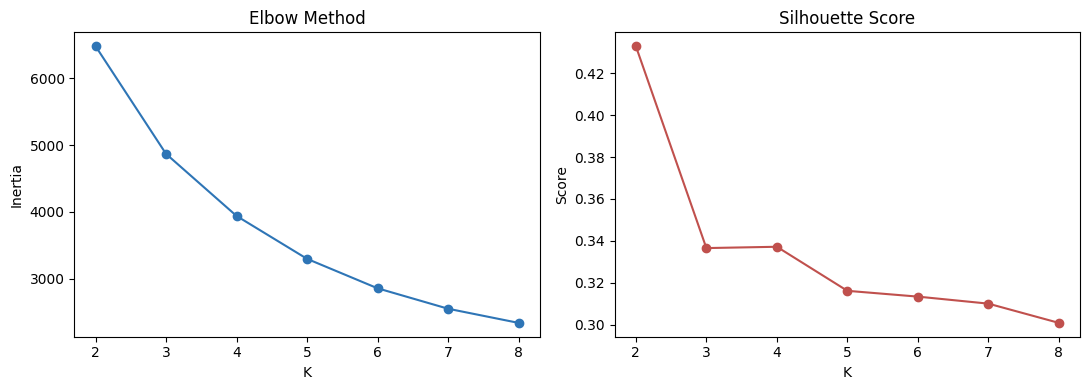

{2: np.float64(0.433), 3: np.float64(0.337), 4: np.float64(0.337), 5: np.float64(0.316), 6: np.float64(0.313), 7: np.float64(0.31), 8: np.float64(0.301)}


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(K_range), inertias, marker="o", color="#2E75B6")
ax1.set_title("Elbow Method"); ax1.set_xlabel("K"); ax1.set_ylabel("Inertia")
ax2.plot(list(K_range), sil_scores, marker="o", color="#C0504D")
ax2.set_title("Silhouette Score"); ax2.set_xlabel("K"); ax2.set_ylabel("Score")
plt.tight_layout()
plt.show()

print(dict(zip(K_range, [round(s,3) for s in sil_scores])))

## Why K=4, not K=2?

Silhouette score is statistically maximized at K=2 (0.433), but a 2-cluster solution
collapses into an uninformative "high spenders vs. everyone else" split — not actionable
for a marketing team that needs to design distinct campaigns.

K=4 is selected instead: it is the first local optimum after K=2 (0.337, only marginally
lower), and produces business-interpretable segments that support differentiated marketing
strategies (loyalty rewards, win-back campaigns, onboarding, etc.). This is a deliberate
trade-off between statistical optimality and business usability.

In [8]:
FINAL_K = 4
km = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
rfm["Cluster"] = km.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, rfm["Cluster"])
print(f"Final Silhouette Score (K={FINAL_K}): {sil:.3f}")

rfm["Cluster"].value_counts().sort_index()
profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
profile["Count"] = rfm["Cluster"].value_counts().sort_index()
profile["Pct"] = (profile["Count"] / profile["Count"].sum() * 100).round(1)
profile

Final Silhouette Score (K=4): 0.337


,Recency,Frequency,Monetary,Count,Pct
Cluster,,,,,
0,18.1,2.1,551.8,837,19.3
1,12.1,13.7,8074.3,716,16.5
2,71.1,4.1,1802.8,1173,27.0
3,182.5,1.3,343.5,1612,37.2


## Segment Labeling Logic

Segments are labeled using Recency AND Monetary jointly — not by spend rank alone.
A cluster with low spend but very recent purchases represents "New" customers worth
nurturing, which is very different from a cluster with low spend and long-dormant
purchases ("Lost" customers, low priority).

In [9]:
order = profile.sort_values("Monetary", ascending=False).index.tolist()
median_recency = profile["Recency"].median()
label_map = {}
for cluster_id in order:
    row = profile.loc[cluster_id]
    if row["Monetary"] == profile["Monetary"].max():
        label_map[cluster_id] = "VIP / Champions"
    elif row["Recency"] >= profile["Recency"].max() * 0.8:
        label_map[cluster_id] = "Lost Customers"
    elif row["Recency"] <= median_recency and row["Monetary"] < profile["Monetary"].median():
        label_map[cluster_id] = "New Customers"
    else:
        label_map[cluster_id] = "Loyal Customers"

rfm["Segment"] = rfm["Cluster"].map(label_map)
profile["Segment"] = profile.index.map(label_map)
profile.sort_values("Monetary", ascending=False)

,Recency,Frequency,Monetary,Count,Pct,Segment
Cluster,,,,,,
1,12.1,13.7,8074.3,716,16.5,VIP / Champions
2,71.1,4.1,1802.8,1173,27.0,Loyal Customers
0,18.1,2.1,551.8,837,19.3,New Customers
3,182.5,1.3,343.5,1612,37.2,Lost Customers


## Segment Visualization

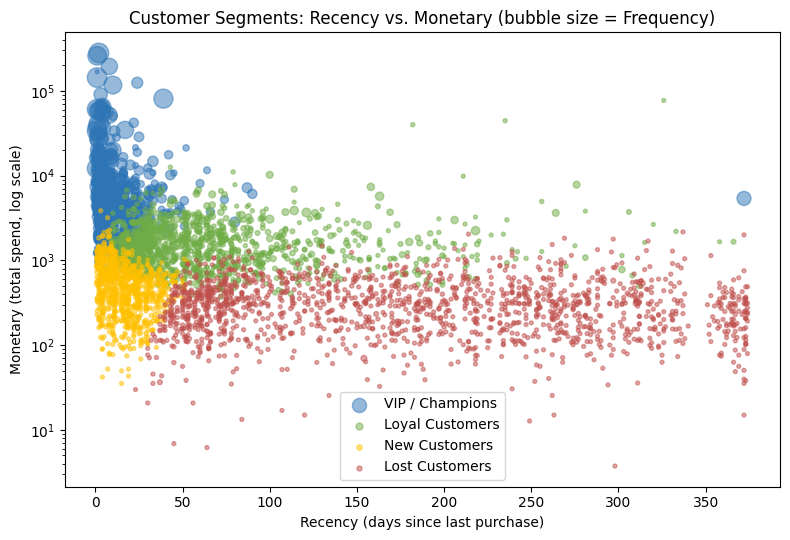

In [10]:
colors = {"VIP / Champions":"#2E75B6", "Loyal Customers":"#70AD47",
          "New Customers":"#FFC000", "Lost Customers":"#C0504D"}

fig, ax = plt.subplots(figsize=(8, 5.5))
for seg, color in colors.items():
    sub = rfm[rfm["Segment"] == seg]
    ax.scatter(sub["Recency"], sub["Monetary"], s=np.clip(sub["Frequency"]*3, 8, 200),
               alpha=0.5, color=color, label=seg)
ax.set_yscale("log")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary (total spend, log scale)")
ax.set_title("Customer Segments: Recency vs. Monetary (bubble size = Frequency)")
ax.legend()
plt.tight_layout()
plt.show()

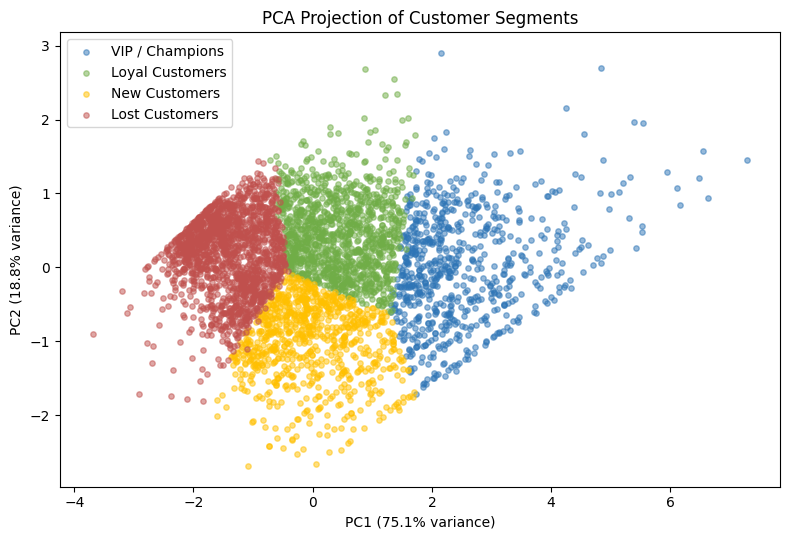

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
rfm["PCA1"], rfm["PCA2"] = pca_result[:,0], pca_result[:,1]

fig, ax = plt.subplots(figsize=(8, 5.5))
for seg, color in colors.items():
    sub = rfm[rfm["Segment"] == seg]
    ax.scatter(sub["PCA1"], sub["PCA2"], alpha=0.5, color=color, label=seg, s=15)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA Projection of Customer Segments")
ax.legend()
plt.tight_layout()
plt.show()

## Segment Comparison — Boxplots

/tmp/ipykernel_913/2065407739.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_seg, labels=colors.keys())
/tmp/ipykernel_913/2065407739.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_seg, labels=colors.keys())
/tmp/ipykernel_913/2065407739.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_seg, labels=colors.keys())


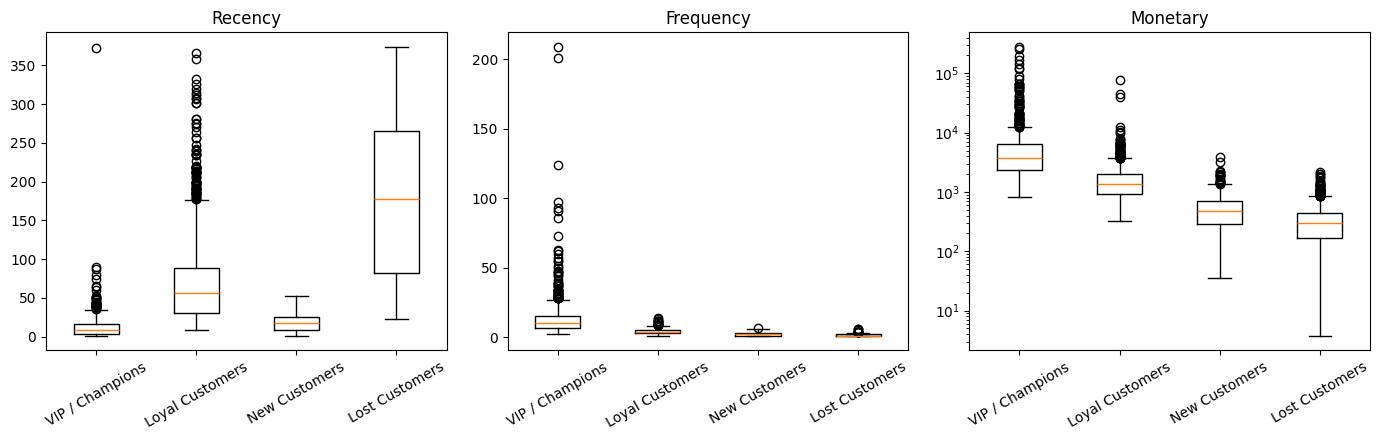

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    data_by_seg = [rfm[rfm["Segment"]==seg][col] for seg in colors.keys()]
    axes[i].boxplot(data_by_seg, labels=colors.keys())
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)
    if col == "Monetary":
        axes[i].set_yscale("log")
plt.tight_layout()
plt.show()

## Statistical Validation: Are Segments Really Different?

Visual separation is not proof. We validate that Monetary value differs significantly
across segments using one-way ANOVA.

In [13]:
from scipy import stats

groups = [rfm[rfm["Segment"]==seg]["Monetary"] for seg in colors.keys()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.2f}, p={p_val:.6f}")
print("Segments differ significantly in Monetary value." if p_val < 0.05 else "No significant difference.")

ANOVA: F=148.32, p=0.000000
Segments differ significantly in Monetary value.


## Post-Hoc Test: Which Specific Segments Differ?

ANOVA confirms that at least one segment differs, but not which pairs. Tukey's HSD
(Honestly Significant Difference) test identifies exactly which segment pairs are
statistically distinguishable while controlling the family-wise error rate at α=0.05 —
the same post-hoc method used in the author's undergraduate thesis for pairwise class
comparisons.

             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
     group1          group2      meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------------------
 Lost Customers Loyal Customers   1459.379 0.0001   614.7423 2304.0156   True
 Lost Customers   New Customers   208.3695 0.9407  -729.2745 1146.0135  False
 Lost Customers VIP / Champions  7730.8168    0.0  6742.3973 8719.2363   True
Loyal Customers   New Customers -1251.0095 0.0069 -2246.8164 -255.2025   True
Loyal Customers VIP / Champions  6271.4379    0.0  5227.6811 7315.1947   True
  New Customers VIP / Champions  7522.4473    0.0  6402.0932 8642.8015   True
-----------------------------------------------------------------------------


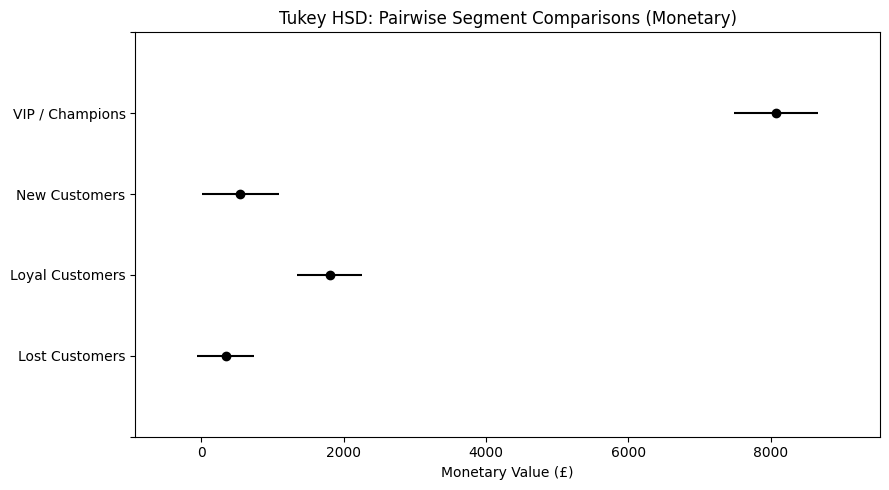

In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=rfm['Monetary'],
    groups=rfm['Segment'],
    alpha=0.05
)

print(tukey)

fig = tukey.plot_simultaneous(figsize=(9, 5))
plt.title("Tukey HSD: Pairwise Segment Comparisons (Monetary)")
plt.xlabel("Monetary Value (£)")
plt.tight_layout()
plt.show()

## Business Recommendations by Segment

| Segment | Profile | Recommended Action |
|---|---|---|
| **VIP / Champions** (16.5%) | Recent, frequent, £8,074 avg. spend | Loyalty rewards, early access to new products, dedicated account support — protect from churn, they drive disproportionate revenue |
| **Loyal Customers** (27.0%) | Moderate recency, steady spend (£1,803) | Cross-sell and upsell campaigns; nurture toward VIP tier |
| **New Customers** (19.3%) | Very recent, low spend so far (£552) | Onboarding email series, welcome discount — build purchase habit before they go dormant |
| **Lost Customers** (37.2%, largest segment) | 182+ days inactive, lowest spend (£344) | Low-cost win-back campaign only — largest group by count but weakest by value; don't over-invest |

**Key insight:** VIP customers (16.5% of the base) generate revenue disproportionate to
their size relative to Lost Customers (37.2%, the largest segment by count) — a classic
Pareto pattern. Marketing spend should be prioritized accordingly rather than treated
uniformly across the customer base.

## Applicability Beyond E-Commerce

The same RFM + K-Means methodology generalizes to subscription-based businesses. For
example, a telecom operator like Unitel could apply this framework to segment mobile
subscribers using:
- **Recency** → days since last recharge or app activity
- **Frequency** → number of recharges or transactions per month
- **Monetary** → ARPU (Average Revenue Per User)

This would identify loyal high-ARPU subscribers (retention priority), churn-risk users
(recent drop in recharge frequency), and new subscribers (onboarding opportunity) —
directly supporting targeted retention campaigns and reducing customer acquisition cost.

## Predictive Extension: Can We Predict Segment Membership?

The clustering above is descriptive — it groups customers based on their complete
purchase history. In practice, a business wants to know a new customer's likely segment
*before* they accumulate months of history, so retention efforts can start early.

This section trains a classifier to predict segment membership using RFM features,
and examines which feature matters most for the prediction.

In [15]:
from sklearn.model_selection import train_test_split

X_features = rfm[["Recency", "Frequency", "Monetary"]]
y_target = rfm["Segment"]

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f"Training set: {len(X_train)} customers")
print(f"Test set: {len(X_test)} customers")

Training set: 3470 customers
Test set: 868 customers


## Model: Random Forest Classifier

Random Forest is chosen for two reasons: it handles the non-linear relationships between
RFM features well, and — more importantly for a business audience — it produces feature
importance scores that are easy to explain without a statistics background.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

 Lost Customers       0.99      0.97      0.98       323
Loyal Customers       0.94      0.96      0.95       235
  New Customers       0.95      0.96      0.96       167
VIP / Champions       0.97      0.98      0.98       143

       accuracy                           0.97       868
      macro avg       0.96      0.97      0.96       868
   weighted avg       0.97      0.97      0.97       868



Recency      0.408161
Monetary     0.305005
Frequency    0.286834
dtype: float64


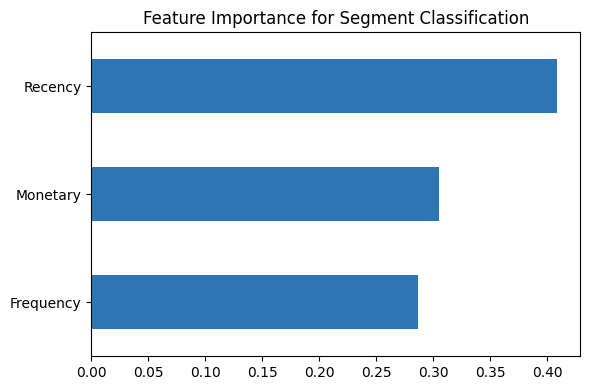

In [18]:
import pandas as pd

importances = pd.Series(clf.feature_importances_, index=X_features.columns).sort_values(ascending=False)
print(importances)

fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", color="#2E75B6", ax=ax)
ax.set_title("Feature Importance for Segment Classification")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart5_feature_importance.png", dpi=150)
plt.show()

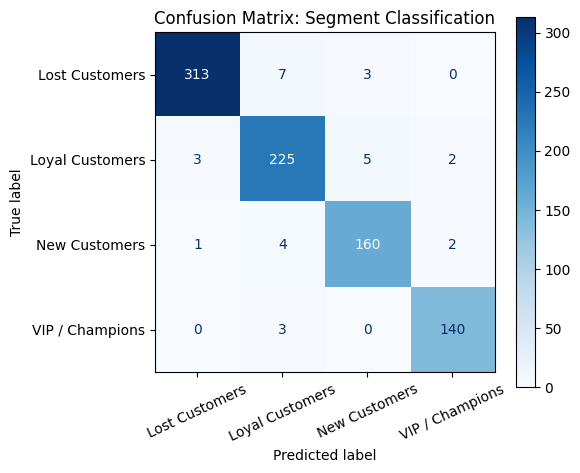

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, ax=ax, cmap="Blues", xticks_rotation=25)
plt.title("Confusion Matrix: Segment Classification")
plt.tight_layout()
plt.savefig("chart6_confusion_matrix.png", dpi=150)
plt.show()

In [20]:
from google.colab import files
files.download("chart5_feature_importance.png")
files.download("chart6_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Early-Lifecycle Prediction: Will a New Customer Become VIP?

The classifier above predicts segment membership from complete purchase history — useful
as a fast lookup, but not a real early-warning tool, since the labels and features come
from the same information. This section asks a genuinely predictive question instead:
using only a customer's first 90 days of behavior, can we forecast whether they will
become a VIP customer over their full lifetime?

To avoid bias from customers who simply haven't had time to be observed, only customers
whose first purchase occurred early enough to have at least 6 months of subsequent history
are included in this analysis.

In [21]:
# Cohort
first_purchase = df.groupby("CustomerID")["InvoiceDate"].min().rename("FirstPurchase")
cutoff = df["InvoiceDate"].max() - pd.Timedelta(days=180)
cohort_ids = first_purchase[first_purchase <= cutoff].index

print(f"Cohort size: {len(cohort_ids)} of {df['CustomerID'].nunique()} total customers")

# Filter for transactions from the first 90 days only.
df_c = df[df["CustomerID"].isin(cohort_ids)].merge(first_purchase, on="CustomerID")
df_c["DaysSinceFirst"] = (df_c["InvoiceDate"] - df_c["FirstPurchase"]).dt.days
early = df_c[df_c["DaysSinceFirst"] <= 90]

early_features = early.groupby("CustomerID").agg(
    Early_Frequency=("InvoiceNo", "nunique"),
    Early_Monetary=("Revenue", "sum"),
    Early_AvgOrderValue=("Revenue", "mean"),
).reset_index()
early_features["Early_Monetary_per_day"] = early_features["Early_Monetary"] / 90

early_features.describe().round(1)

Cohort size: 2815 of 4338 total customers


,CustomerID,Early_Frequency,Early_Monetary,Early_AvgOrderValue,Early_Monetary_per_day
count,2815.0,2815.0,2815.0,2815.0,2815.0
mean,15297.4,2.1,918.9,70.2,10.2
std,1715.3,2.2,2681.6,1482.3,29.8
min,12346.0,1.0,0.8,0.8,0.0
25%,13822.5,1.0,232.8,13.0,2.6
50%,15251.0,1.0,430.5,18.2,4.8
75%,16770.5,2.0,900.0,26.3,10.0
max,18287.0,44.0,77183.6,77183.6,857.6


In [22]:
labels = rfm[rfm["CustomerID"].isin(cohort_ids)][["CustomerID", "Segment"]]
early_labeled = early_features.merge(labels, on="CustomerID")
early_labeled["IsVIP"] = (early_labeled["Segment"] == "VIP / Champions").astype(int)

print(early_labeled["IsVIP"].value_counts())

IsVIP
0    2172
1     643
Name: count, dtype: int64


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

X2 = early_labeled[["Early_Frequency", "Early_Monetary", "Early_AvgOrderValue"]]
y2 = early_labeled["IsVIP"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2
)

log_clf = LogisticRegression(class_weight="balanced")
log_clf.fit(X2_train, y2_train)

y2_proba = log_clf.predict_proba(X2_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y2_test, y2_proba):.3f}")
print(classification_report(y2_test, log_clf.predict(X2_test)))

ROC-AUC: 0.884
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       543
           1       0.64      0.71      0.67       161

    accuracy                           0.84       704
   macro avg       0.78      0.80      0.79       704
weighted avg       0.85      0.84      0.85       704



## Limitations & Future Work

- RFM treats all customers equally regardless of product category — a future iteration
  could segment within product categories separately
- K-Means assumes spherical clusters; Gaussian Mixture Models or DBSCAN could be
  compared for robustness (planned extension)
-The predictive model uses only RFM features; incorporating product-category
  preferences or browsing behavior (if available) could improve early-lifecycle
  prediction accuracy further
  # Future Roadmap

Phase 1

Descriptive Analytics

(RFM Customer Segmentation)

↓

Phase 2

Predictive Analytics

(Customer Churn Prediction using XGBoost)

↓

Phase 3

Prescriptive Analytics

(Personalized Marketing Optimization)

↓

Phase 4

Production Deployment

(API + Dashboard + Automated Pipeline)

# Business Impact

If implemented in production, this segmentation model could help businesses:

- Personalize marketing campaigns instead of mass targeting.
- Improve customer retention by identifying churn-risk customers early.
- Increase Customer Lifetime Value (CLV).
- Allocate marketing budgets more efficiently.
- Improve executive decision-making through customer insights.
- Reduce unnecessary promotional spending on low-value customers.

The same analytical framework can also be applied to telecom, banking, subscription, insurance, and fintech industries.

In [17]:
rfm.to_csv("customer_segments.csv", index=False)
profile.to_csv("cluster_profile.csv")
from google.colab import files

for f in ["customer_segments.csv", "cluster_profile.csv"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>